In [45]:
import pandas as pd
import numpy as np

In [46]:
df = pd.read_csv('all datas.csv')

In [47]:
df.head(15)

,Job Title,Company Name,Location,Experience,Salary,Skills,Description
0,business management - associate,JPMorgan Chase Bank,Bengaluru,8-15 Yrs,Not disclosed,"Excel, Business analysis, Time management, Bus...","Bachelor s degree in Business, Finance, Econom..."
1,business management associate - freshers only,Dexterous Inc,Bengaluru,8-15 Yrs,Not disclosed,"Marketing, bcom, fresher, graduate, Business D...","Bachelor s degree in Business, Finance, Econom..."
2,urgent hiring _ business associate (your manag...,Mettle Minds,Bengaluru,8-15 Yrs,Not disclosed,"immediate joiners, Malayalam, Communication Sk...","Bachelor s degree in Business, Finance, Econom..."
3,"business management team, associate",Deutsche Bank,Bengaluru,8-15 Yrs,Not disclosed,"Business Management, Business Continuity Manag...","Bachelor s degree in Business, Finance, Econom..."
4,business management and development - freshers,Caliber Organisation,Bengaluru,8-15 Yrs,Not disclosed,"Business Development, Client Management, Commu...","Bachelor s degree in Business, Finance, Econom..."
5,business management associate,Caliber Organisation,Bengaluru,8-15 Yrs,Not disclosed,"FRESHER, graduate, COMMUNICATION, Decision Mak...","Bachelor s degree in Business, Finance, Econom..."
6,business management associate - freshers only,Caliber Organisation,Bengaluru,8-15 Yrs,Not disclosed,"Business Management, Corporate Trainee, Busine...","Bachelor s degree in Business, Finance, Econom..."
7,business management associate,Abdoolally Ebrahim Housewares Limited,Bengaluru,8-15 Yrs,Not disclosed,"Business development, B2B, Business Growth, bu...","Bachelor s degree in Business, Finance, Econom..."
8,hiring for freelancing- business management gr...,Firstsource,Bengaluru,8-15 Yrs,Not disclosed,"Human Resource Management, Business Administra...","Bachelor s degree in Business, Finance, Econom..."
9,business management senior analyst - associate,Deutsche Bank,Bengaluru,8-15 Yrs,Not disclosed,"risk management, data analytics, operational r...","Bachelor s degree in Business, Finance, Econom..."


In [48]:
df['Job Title'].value_counts()

Job Title
application developer                               3640
business analyst                                    3374
business development manager                        2754
senior software engineer                            1580
devops engineer                                     1231
                                                    ... 
senior audit executive - inter ca - mulund             1
head of accounts and administration                    1
account and commercial manager                         1
accountant 3-5 years vile parle - andheri mumbai       1
room divisions manager                                 1
Name: count, Length: 68009, dtype: int64

Dealing with Job Title

In [55]:
import re
roles_pattern = r'(Developer|Engineer|Analyst|Manager|Executive|Associate|Architect|Consultant|Scientist|Administrator)'
df['Core_Role']=df['Job Title'].str.extract(roles_pattern,flags=re.IGNORECASE,expand=False)

In [56]:
level_pattern = r'(Senior|Sr|Junior|Jr|Lead|Principal|Director|Trainee|Intern|Head|VP|Vice President)'
df['Seniority'] = df['Job Title'].str.extract(level_pattern,flags=re.IGNORECASE, expand=False)

In [59]:
df['Core_Role'] = df['Core_Role'].str.title().fillna('Others')
df['Seniority'] = df['Seniority'].str.title().fillna('Unspecified')

In [60]:
df[['Job Title','Seniority','Core_Role']].head(15)

,Job Title,Seniority,Core_Role
0,business management - associate,Unspecified,Associate
1,business management associate - freshers only,Unspecified,Associate
2,urgent hiring _ business associate (your manag...,Unspecified,Associate
3,"business management team, associate",Unspecified,Associate
4,business management and development - freshers,Unspecified,Others
5,business management associate,Unspecified,Associate
6,business management associate - freshers only,Unspecified,Associate
7,business management associate,Unspecified,Associate
8,hiring for freelancing- business management gr...,Unspecified,Others
9,business management senior analyst - associate,Senior,Analyst


In [63]:
df['Core_Role'].describe()

count     153428
unique        11
top       Others
freq       44676
Name: Core_Role, dtype: object

In [64]:
df['Seniority'].describe()

count          153428
unique             13
top       Unspecified
freq           116390
Name: Seniority, dtype: object

In [65]:
df.sample(8)

,Job Title,Company Name,Location,Experience,Salary,Skills,Description,Core_Role,Seniority,Senority
122351,application developer,Accenture,Bengaluru,3-8 Yrs,Not disclosed,"microsoft dynamics, microsoft azure, applicati...",We are looking for Strong Python Developer wit...,Developer,Unspecified,Unspecified
66883,"senior associate, ai and data science full sta...",Pfizer,Kochi,2-7 Yrs,Not disclosed,"Computer science, data science, Machine learni...",Shift from manual decision-making to data-driv...,Associate,Senior,Senior
28656,data architect,SBM Offshore,Bengaluru,7-10 Yrs,Not disclosed,"Computer science, Data analysis, ERP, SAP, Dat...",He / she must be able to develop ETL / ELT pip...,Architect,Unspecified,Unspecified
42374,senior financial analyst,Right Step Consulting,Pune,2-5 Yrs,14-20 Lacs PA,"Senior Financial Analyst, Analytical, Financia...",Interested Candidates can share there CV on pr...,Analyst,Senior,Senior
4133,manager international business development,Pravin Masalewale,"Bengaluru, MG Road, Indira Nagar",1-5 Yrs,Not disclosed,"International Business Development, Internatio...",The Role: Develop good relations with pan-Indi...,Manager,Intern,Intern
56767,senior associate - finance and accounts,Aster DM Healthcare,Nashik,4-5 Yrs,Not disclosed,"ledger, accounts receivable, accounts payable,...",Should handle quarterly and year end financial...,Associate,Senior,Senior
94690,front desk manager,Savvi Sales & Services,Lucknow,3-8 Yrs,Not disclosed,"Data Entry, Computer Skills, Good English Comm...",Smooth Processing of Claim Reserve Setting Lin...,Manager,Unspecified,Unspecified
50220,record to report ops analyst,Accenture,Jaipur,5-10 Yrs,Not disclosed,"balance sheet, sap, cash management, visio, re...",Minimum . 5 year(s) of experience is required....,Analyst,Unspecified,Unspecified


Dealing with Company Name

In [66]:
df['Company Name'].value_counts()

Company Name
Accenture                                                   9578
Leading Client                                              2173
Amazon                                                      1621
Capgemini                                                   1178
PwC Service Delivery Center                                 1109
                                                            ... 
Mount Housing And Infrastructure Limited                       1
Sharangdhar Pharmaceuticals                                    1
"We are hiring for "Pizza Chef" for an leading Fine Dine       1
HG Consultancy                                                 1
Anujai Security Services                                       1
Name: count, Length: 35345, dtype: int64

In [67]:
df['Company Name'].describe()

count        153428
unique        35345
top       Accenture
freq           9578
Name: Company Name, dtype: object

In [79]:
df['Company_clean']=df['Company Name'].str.strip().str.title()
df['Company_clean']=df['Company_clean'].str.replace('"','',regex=False)
hidden_keywords = 'Leading Client|Confidential|Undisclosed|Top Mnc|Leading Mnc'
df.loc[df['Company_clean'].str.contains(hidden_keywords,case=False,na=False),'Company_clean'] = 'Confidential'
long_name_mask = df['Company_clean'].str.len()>50
df.loc[long_name_mask,'Company_clean'] = 'Invalid Data'


In [80]:
df['Company_clean']=df['Company_clean'].str.replace(' ','_')
df['Company_clean'] = df['Company_clean'].str.lower()
df['Company_clean'].head(10)

0                      jpmorgan_chase_bank
1                            dexterous_inc
2                             mettle_minds
3                            deutsche_bank
4                     caliber_organisation
5                     caliber_organisation
6                     caliber_organisation
7    abdoolally_ebrahim_housewares_limited
8                              firstsource
9                            deutsche_bank
Name: Company_clean, dtype: object

Starting with Location

In [83]:
df['Location'].value_counts()

Location
Bengaluru                                                    30073
Hyderabad                                                    10867
Mumbai                                                        9998
Pune                                                          9566
Gurugram                                                      7312
                                                             ...  
Cuttack, Jajpur, Jeypur, Kandhamal, Jharsuguda, Kalahandi        1
Medinipur, Uluberia, Dakshin Dinajpur                            1
Bandipora, Doda, Anantnag, Tangmarg, Una, Budgam                 1
Faizabad, Amroha, Azamgarh, Nagar, Auraiya, Amethi               1
Kolkata, Patna, Ranchi                                           1
Name: count, Length: 1251, dtype: int64

In [84]:
location_category = r'(Bengaluru|Hyderabad|Mumbai|Pune|Gurugram)'
df['Location'] = df['Location'].str.extract(location_category,flags=re.IGNORECASE, expand=False)

In [85]:
df['Location'] = df['Location'].str.title().fillna('Others')

In [87]:
df['Location'].describe()

count     153428
unique         6
top       Others
freq       62505
Name: Location, dtype: object

starting with Experience


In [88]:
experience_extracted = df['Experience'].str.extract(r'(\d+)\s*-\s*(\d+)')
df['Min_Experience_Yrs'] = experience_extracted[0].astype(float)
df['Max_Experience_Yrs'] = experience_extracted[1].astype(float)
df['Avg_Experience_Yrs'] = (df['Min_Experience_Yrs'] + df['Max_Experience_Yrs'])/2
df[['Experience', 'Min_Experience_Yrs', 'Max_Experience_Yrs', 'Avg_Experience_Yrs']].head(10)

,Experience,Min_Experience_Yrs,Max_Experience_Yrs,Avg_Experience_Yrs
0,8-15 Yrs,8.0,15.0,11.5
1,8-15 Yrs,8.0,15.0,11.5
2,8-15 Yrs,8.0,15.0,11.5
3,8-15 Yrs,8.0,15.0,11.5
4,8-15 Yrs,8.0,15.0,11.5
5,8-15 Yrs,8.0,15.0,11.5
6,8-15 Yrs,8.0,15.0,11.5
7,8-15 Yrs,8.0,15.0,11.5
8,8-15 Yrs,8.0,15.0,11.5
9,8-15 Yrs,8.0,15.0,11.5


In [90]:
df['Avg_Experience_Yrs'].describe()

count    152008.000000
mean          4.940651
std           3.510649
min           0.500000
25%           2.500000
50%           4.000000
75%           6.500000
max          27.500000
Name: Avg_Experience_Yrs, dtype: float64

Dealing with Skills


In [93]:
df['Total_Skills'] = df['Skills'].str.split(',').str.len().fillna(0)
df['Total_Skills'].head(10)

0    8
1    8
2    8
3    8
4    8
5    8
6    8
7    8
8    8
9    8
Name: Total_Skills, dtype: int64

In [94]:
df['Skills'].value_counts()

Skills
Counselor, Mentor, Trainer, Advisor, Educator, Teaching, advisory, mentoring                                                                                     514
Counselor, Mentor, Trainer, Advisor, Educator, Teaching, Education, Advisory                                                                                     431
image editing, art, business cards, visualiser, brochure design, user interface designing, adobe after effects, posters                                          335
Business Analyst, Business analysis                                                                                                                              239
Counselor, Mentor, Trainer, Advisor, Educator, Teaching, Mentoring, Education                                                                                    188
                                                                                                                                                                ... 
Hum

In [97]:
clean_skills = df['Skills'].fillna('').str.lower()
skill_groups = {
    'Skill_Education': r'(teach|educat|mentor|train|counsel|advis)',
    'Skill_Design': r'(design|art|image edit|adobe|visual)',
    'Skill_Business_Analysis': r'(business analy|ba|requirement)'
}
for col_name, regex_pattern in skill_groups.items():
   
    df[col_name] = clean_skills.str.contains(regex_pattern, regex=True).astype(int)  
df['Total_Skills_Listed'] = df['Skills'].str.split(',').str.len().fillna(0)
df[['Skills', 'Total_Skills_Listed', 'Skill_Education', 'Skill_Design', 'Skill_Business_Analysis']].sample(10)

C:\Users\ayush\AppData\Local\Temp\ipykernel_21388\2649771712.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col_name] = clean_skills.str.contains(regex_pattern, regex=True).astype(int)
C:\Users\ayush\AppData\Local\Temp\ipykernel_21388\2649771712.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col_name] = clean_skills.str.contains(regex_pattern, regex=True).astype(int)
C:\Users\ayush\AppData\Local\Temp\ipykernel_21388\2649771712.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col_name] = clean_skills.str.contains(regex_pattern, regex=True).astype(int)


,Skills,Total_Skills_Listed,Skill_Education,Skill_Design,Skill_Business_Analysis
66160,"Data analysis, Statistical modeling, Neural ne...",8,0,0,0
80299,"Blog Writing, Content Writing, Creative Writin...",8,0,0,0
71698,"AI, LLM, Machine Learning, Azure, Artificial I...",8,0,1,0
70008,"Computer vision, NoSQL, GCP, Machine learning,...",8,0,0,0
120009,"Unix, Computer science, SAN, Core Java, Linux,...",8,0,0,0
135093,"experience, web designer, Design, Web technolo...",5,0,1,0
99733,"project management, software testing, function...",8,0,0,1
14677,"Backend, Incharge, Sales, devops, Management, ...",8,0,0,1
118194,"Object oriented design, Product quality, Autom...",8,1,1,0
567,"Product management, Interpersonal skills, Seni...",8,0,0,0


In [98]:
df = df.drop(columns=['Description'])

Salary


In [101]:
df['Salary'].value_counts()

Salary
Not disclosed        127124
Unpaid                 1147
3-5 Lacs PA             586
3-6 Lacs PA             517
3-4 Lacs PA             385
                      ...  
3.25-3.75 Lacs PA         6
2-5.5 Lacs PA             5
3.25-4.5 Lacs PA          5
4.2-7.2 Lacs PA           5
Salary                    2
Name: count, Length: 406, dtype: int64

In [107]:
bad_salaries = ['Not disclosed', 'Unpaid', 'Salary']
df_clean = df[~df['Salary'].isin(bad_salaries)].copy()

In [108]:
salary_extracted = df_clean['Salary'].str.extract(r'([\d.]+)\s*-\s*([\d.]+)')

In [109]:
df_clean['Min_Salary_Lakhs'] = salary_extracted[0].astype(float)
df_clean['Max_Salary_Lakhs'] = salary_extracted[1].astype(float)

In [110]:
df_clean['Target_Salary_Lakhs'] = (df_clean['Min_Salary_Lakhs'] + df_clean['Max_Salary_Lakhs']) / 2
print(f"Total rows remaining for machine learning: {len(df_clean)}")
df_clean[['Salary', 'Min_Salary_Lakhs', 'Max_Salary_Lakhs', 'Target_Salary_Lakhs']].head(10)

Total rows remaining for machine learning: 25155


,Salary,Min_Salary_Lakhs,Max_Salary_Lakhs,Target_Salary_Lakhs
20,3-5 Lacs PA,3.0,5.0,4.0
21,3-5 Lacs PA,3.0,5.0,4.0
22,3-5 Lacs PA,3.0,5.0,4.0
23,3-5 Lacs PA,3.0,5.0,4.0
24,3-5 Lacs PA,3.0,5.0,4.0
25,3-5 Lacs PA,3.0,5.0,4.0
26,3-5 Lacs PA,3.0,5.0,4.0
27,3-5 Lacs PA,3.0,5.0,4.0
28,3-5 Lacs PA,3.0,5.0,4.0
29,3-5 Lacs PA,3.0,5.0,4.0


In [113]:
df_clean['Target_Salary_Lakhs'].value_counts()

Target_Salary_Lakhs
4.500     868
4.000     842
3.500     774
3.000     725
10.000    675
         ... 
1.320      18
3.180      18
6.375      16
6.125      15
5.700       5
Name: count, Length: 138, dtype: int64

In [115]:
print(df_clean.corr(numeric_only=True)['Target_Salary_Lakhs'].sort_values(ascending=False))

Target_Salary_Lakhs        1.000000
Max_Salary_Lakhs           0.981479
Min_Salary_Lakhs           0.961913
Avg_Experience_Yrs         0.573625
Max_Experience_Yrs         0.567597
Min_Experience_Yrs         0.561457
Total_Skills               0.043993
Total_Skills_Listed        0.043993
Skill_Design               0.029996
Skill_Business_Analysis    0.014062
Skill_Education           -0.095051
Name: Target_Salary_Lakhs, dtype: float64


Model Training

In [117]:
df_clean = df_clean.drop(columns=['Senority'], errors='ignore')

In [130]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25155 entries, 20 to 153352
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Job Title                25155 non-null  object 
 1   Company Name             25155 non-null  object 
 2   Location                 25155 non-null  object 
 3   Experience               25155 non-null  object 
 4   Salary                   25155 non-null  object 
 5   Skills                   25155 non-null  object 
 6   Core_Role                25155 non-null  object 
 7   Seniority                25155 non-null  object 
 8   Company_clean            25155 non-null  object 
 9   Min_Experience_Yrs       24278 non-null  float64
 10  Max_Experience_Yrs       24278 non-null  float64
 11  Avg_Experience_Yrs       24278 non-null  float64
 12  Total_Skills             25155 non-null  int64  
 13  Skill_Education          25155 non-null  int64  
 14  Skill_Design             

In [131]:
df_clean.head()

,Job Title,Company Name,Location,Experience,Salary,Skills,Core_Role,Seniority,Company_clean,Min_Experience_Yrs,Max_Experience_Yrs,Avg_Experience_Yrs,Total_Skills,Skill_Education,Skill_Design,Skill_Business_Analysis,Total_Skills_Listed,Min_Salary_Lakhs,Max_Salary_Lakhs,Target_Salary_Lakhs
20,business management trainee (any stream freshe...,Greymatterinc.in,Others,0-1 Yrs,3-5 Lacs PA,"Management, BBA, BCOM, Leadership, Pressure Ha...",Others,Trainee,greymatterinc.in,0.0,1.0,0.5,8,0,0,1,8,3.0,5.0,4.0
21,massive hiring !!!! business management role a...,Mayank Singh,Others,0-1 Yrs,3-5 Lacs PA,"Marketing, Communication Skills, B2B, Team Bui...",Others,Unspecified,mayank_singh,0.0,1.0,0.5,8,0,0,0,8,3.0,5.0,4.0
22,great opportunity for freshers : business mana...,Solitaire Incorporation,Others,0-1 Yrs,3-5 Lacs PA,"Marketing, Communication Skills, Team Building...",Others,Unspecified,solitaire_incorporation,0.0,1.0,0.5,8,0,0,0,8,3.0,5.0,4.0
23,hiring for business management role - fresher/...,Height Inc,Others,0-1 Yrs,3-5 Lacs PA,"Marketing, Creative Skills, Planning Skills, C...",Others,Unspecified,height_inc,0.0,1.0,0.5,8,0,0,1,8,3.0,5.0,4.0
24,international business management role any gra...,Wikreate Organisation,Others,0-1 Yrs,3-5 Lacs PA,"problem-solving, Leadership, Time Management, ...",Others,Intern,wikreate_organisation,0.0,1.0,0.5,8,0,0,0,8,3.0,5.0,4.0


In [134]:
df_clean = df_clean.drop(columns=['Company Name','Experience','Salary','Skills','Min_Experience_Yrs','Max_Experience_Yrs','Min_Salary_Lakhs','Max_Salary_Lakhs'])

In [135]:
df_clean.head()

,Job Title,Location,Core_Role,Seniority,Company_clean,Avg_Experience_Yrs,Total_Skills,Skill_Education,Skill_Design,Skill_Business_Analysis,Total_Skills_Listed,Target_Salary_Lakhs
20,business management trainee (any stream freshe...,Others,Others,Trainee,greymatterinc.in,0.5,8,0,0,1,8,4.0
21,massive hiring !!!! business management role a...,Others,Others,Unspecified,mayank_singh,0.5,8,0,0,0,8,4.0
22,great opportunity for freshers : business mana...,Others,Others,Unspecified,solitaire_incorporation,0.5,8,0,0,0,8,4.0
23,hiring for business management role - fresher/...,Others,Others,Unspecified,height_inc,0.5,8,0,0,1,8,4.0
24,international business management role any gra...,Others,Others,Intern,wikreate_organisation,0.5,8,0,0,0,8,4.0


In [136]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25155 entries, 20 to 153352
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Job Title                25155 non-null  object 
 1   Location                 25155 non-null  object 
 2   Core_Role                25155 non-null  object 
 3   Seniority                25155 non-null  object 
 4   Company_clean            25155 non-null  object 
 5   Avg_Experience_Yrs       24278 non-null  float64
 6   Total_Skills             25155 non-null  int64  
 7   Skill_Education          25155 non-null  int64  
 8   Skill_Design             25155 non-null  int64  
 9   Skill_Business_Analysis  25155 non-null  int64  
 10  Total_Skills_Listed      25155 non-null  int64  
 11  Target_Salary_Lakhs      24482 non-null  float64
dtypes: float64(2), int64(5), object(5)
memory usage: 2.5+ MB


In [138]:
df_ready = df_clean.dropna(subset=['Target_Salary_Lakhs']).copy()

In [139]:
cols_to_drop = ['Job Title', 'Location', 'Total_Skills_Listed']
df_ready = df_ready.drop(columns=cols_to_drop, errors='ignore')

Train Test Split

In [140]:
X = df_ready.drop(columns=['Target_Salary_Lakhs'])
y = df_ready['Target_Salary_Lakhs']

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [143]:
numeric_features = ['Avg_Experience_Yrs', 'Total_Skills', 'Skill_Education', 'Skill_Design', 'Skill_Business_Analysis']
categorical_features = ['Core_Role', 'Seniority', 'Company_clean']

In [144]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
])

In [145]:
numeric_transformer = SimpleImputer(strategy='median')

In [146]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [160]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1))
])

In [161]:
from sklearn import set_config
set_config(display='diagram')

In [162]:
model_pipeline

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [163]:
model_pipeline.fit(X_train, y_train)
print("Pipeline successfully built and trained!")

Pipeline successfully built and trained!


In [164]:
from sklearn.metrics import r2_score , mean_absolute_error
y_pred = model_pipeline.predict(X_test)
print(f"r2_score:{r2_score(y_test,y_pred)}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred)}")

r2_score:0.5082026054756372
mean_absolute_error:4.0099947365369


In [165]:
from xgboost import XGBRegressor

xgboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('regressor', XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42))
])

xgboost_pipeline.fit(X_train, y_train)

xgb_pred = xgboost_pipeline.predict(X_test)

print(f"New XGBoost R2 Score: {r2_score(y_test, xgb_pred):.4f}")
print(f"New XGBoost MAE: {mean_absolute_error(y_test, xgb_pred):.4f}")

New XGBoost R2 Score: 0.5254
New XGBoost MAE: 4.8859


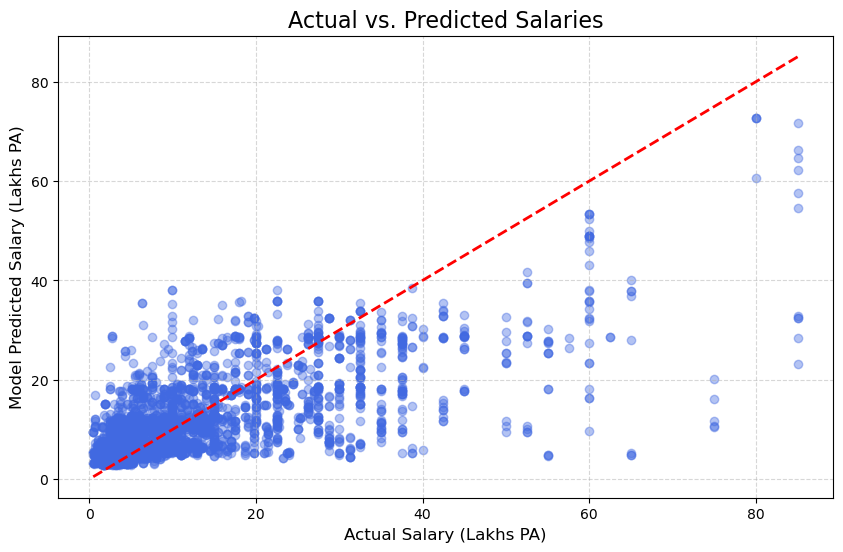

In [166]:
import matplotlib.pyplot as plt

y_pred = xgboost_pipeline.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.4, color='royalblue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

plt.title('Actual vs. Predicted Salaries', fontsize=16)
plt.xlabel('Actual Salary (Lakhs PA)', fontsize=12)
plt.ylabel('Model Predicted Salary (Lakhs PA)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()